In [10]:
import numpy as np
import pandas as pd

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GroupKFold, HalvingGridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

import os

#Running on Google Colab = True/locally = False
colab = True

### Get the File Location of the Dataset

In [2]:
dataset_path = os.getcwd()
# print(os.listdir(dataset_path))
if colab:
  dataset_path = os.path.join(dataset_path, os.listdir(dataset_path)[1])
else:
  dataset_path = os.path.join(dataset_path, "Final_Dataset")
  dataset_path = os.path.join(dataset_path, os.listdir(dataset_path)[0])
print(dataset_path)

data = pd.read_csv(dataset_path)
# print(data)
X = data.iloc[:, 0:data.shape[1]-1].values
# print(X)
y = data.iloc[:, data.shape[1]-1].values

/content/concatenated_data.csv


### Create the SVR Model

#### Resources:
1. https://www.analyticsvidhya.com/blog/2020/03/support-vector-regression-tutorial-for-machine-learning/
2. https://scikit-learn.org/1.5/modules/generated/sklearn.svm.SVR.html
3. Picking which kernel should be used for linear and non-linear relationships: https://www.geeksforgeeks.org/support-vector-regression-svr-using-linear-and-non-linear-kernels-in-scikit-learn/
4. https://www.geeksforgeeks.org/time-series-forecasting-with-support-vector-regression/
5. https://www.geeksforgeeks.org/ml-feature-scaling-part-2/

Note: Our dataset may need to use a kernel that is applicable for non-linear relationships since time-series data is prone to alot of changes.

### Creating the Train-Test Split

#### Resources:
1. https://www.geeksforgeeks.org/how-to-generate-a-train-test-split-based-on-a-group-id/#importance-of-groupbased-splitting

### Generating the Metrics:

#### Resources:
1. https://scikit-learn.org/1.5/modules/model_evaluation.html#r2-score-the-coefficient-of-determination
2. https://scikit-learn.org/1.5/modules/model_evaluation.html#mean-squared-error

In [3]:
##Without Using MinMaxScalar

##Default Hyperparmeters: C = 1
svr_model = SVR(kernel = 'rbf')
##Overall there are 25 groups since there are 25 patient IDs
kfold_split = GroupKFold(n_splits = 5)
groups = X[:, 0]
r2_scores, rmse_vals = [], []
# Apply splits while ensuring patient grouping is maintained
split_num = 1
for train_index, test_index in kfold_split.split(data, groups = groups):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print(f"Unique classes in TRAIN: {np.unique(X_train[:,0])}")
    print(f"Unique classes in TEST: {np.unique(X_test[:,0])}")
    # print(f"TRAIN shapes: X: {X_train.shape}, y: {y_train.shape}")
    # print(f"TEST shapes: X: {X_test.shape}, y: {y_test.shape}")

    X_train, X_test = X_train[:, 1:], X_test[:, 1:]

    #Fit the model
    svr_model.fit(X_train, y_train)

    # Predict
    y_pred = svr_model.predict(X_test)

    # Calculate r2
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Split Num: {split_num}")
    print(f"R2 Score: {r2}")
    print(f"RMSE: {np.sqrt(mse)}")
    r2_scores.append(r2)
    rmse_vals.append(np.sqrt(mse))
    split_num += 1

Unique classes in TRAIN: [ 2.  3.  4.  5.  6.  9. 10. 11. 12. 13. 15. 16. 18. 19. 20. 21. 22. 23.
 24. 25.]
Unique classes in TEST: [ 1.  7.  8. 14. 17.]
Split Num: 1
R2 Score: 0.3695008705920305
RMSE: 5.507925371296755
Unique classes in TRAIN: [ 1.  2.  3.  5.  6.  7.  8. 10. 12. 13. 14. 15. 16. 17. 18. 19. 21. 22.
 23. 25.]
Unique classes in TEST: [ 4.  9. 11. 20. 24.]
Split Num: 2
R2 Score: 0.3453360181415698
RMSE: 5.611094862199112
Unique classes in TRAIN: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 14. 17. 19. 20. 21. 22.
 23. 24.]
Unique classes in TEST: [13. 15. 16. 18. 25.]
Split Num: 3
R2 Score: 0.3435566000545833
RMSE: 5.616613494627427
Unique classes in TRAIN: [ 1.  2.  4.  7.  8.  9. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22.
 24. 25.]
Unique classes in TEST: [ 3.  5.  6. 10. 23.]
Split Num: 4
R2 Score: 0.3237008573997606
RMSE: 5.714665234585956
Unique classes in TRAIN: [ 1.  3.  4.  5.  6.  7.  8.  9. 10. 11. 13. 14. 15. 16. 17. 18. 20. 23.
 24. 25.]
Unique class

In [4]:
r2_scores, rmse_vals = np.array(r2_scores), np.array(rmse_vals)
avg_r2 = np.mean(r2_scores)
avg_rmse = np.mean(rmse_vals)
print(f"Average R2 Score: {avg_r2}")
print(f"Average RMSE: {avg_rmse}")

Average R2 Score: 0.31991425728153117
Average RMSE: 5.715812178760275


In [13]:
##Using MinMaxScalar for Standardization
svr_model = SVR(kernel = 'rbf')
scaler = MinMaxScaler()

##Overall there are 25 groups since there are 25 patient IDs
ts_split = GroupKFold(n_splits = 5)
groups = X[:, 0]
min_max_r2_scores, min_max_rmse_vals = [], []
# Apply splits while ensuring patient grouping is maintained
split_num = 1
for train_index, test_index in ts_split.split(data, groups = groups):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # print(f"Unique classes in TRAIN: {np.unique(X_train[:,0])}")
    # print(f"Unique classes in TEST: {np.unique(X_test[:,0])}")
    # print(f"TRAIN shapes: X: {X_train.shape}, y: {y_train.shape}")
    # print(f"TEST shapes: X: {X_test.shape}, y: {y_test.shape}")

    X_train_cyclical, X_test_cyclical = X_train[:, 1:3], X_test[:, 1:3]
    # print(X_train_cyclical)
    # print(X_test_cyclical)
    X_train, X_test = X_train[:, 3:], X_test[:, 3:]
    # print(X_train)
    # print(X_test)

    scaled_X_train = scaler.fit_transform(X_train)
    scaled_X_test = scaler.transform(X_test)

    scaled_X_train = np.concatenate((X_train_cyclical, scaled_X_train), axis = 1)
    scaled_X_test = np.concatenate((X_test_cyclical, scaled_X_test), axis = 1)
    # print("X_train = ", scaled_X_train)
    # print("X_test = ", scaled_X_test)

    svr_model.fit(scaled_X_train, y_train)

    y_pred = svr_model.predict(scaled_X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Split Num: {split_num}")
    print(f"R2 Score: {r2}")
    print(f"RMSE: {np.sqrt(mse)}")
    print(f"Y_PRED: {y_pred}")
    min_max_r2_scores.append(r2)
    min_max_rmse_vals.append(np.sqrt(mse))
    split_num += 1

Split Num: 1
R2 Score: 0.896792799380012
RMSE: 2.2284392584928376
Y_PRED: [18.77234804 18.85407047 18.92399395 ... 18.61955252 18.71849304
 18.80965711]
Split Num: 2
R2 Score: 0.8975384174154392
RMSE: 2.219825913853096
Y_PRED: [15.59862203 15.6672802  15.74545431 ... 22.40728749 22.21045636
 22.27834467]
Split Num: 3
R2 Score: 0.8973495263432631
RMSE: 2.22103997309354
Y_PRED: [16.22967244 16.30029611 16.37202929 ... 13.60962793 13.70178302
 13.79066486]
Split Num: 4
R2 Score: 0.8969338063886168
RMSE: 2.230896872563998
Y_PRED: [22.52479555 22.52650223 22.62901041 ... 11.04584767 10.29373412
  9.55978279]
Split Num: 5
R2 Score: 0.8918401819583948
RMSE: 2.2785426045204256
Y_PRED: [20.05787417 19.62873997 19.11643664 ... 11.41724078 11.49292454
 11.56797143]


In [14]:
min_max_r2_scores, min_max_rmse_vals = np.array(min_max_r2_scores), np.array(min_max_rmse_vals)
min_max_avg_r2 = np.mean(min_max_r2_scores)
min_max_avg_rmse = np.mean(min_max_rmse_vals)
print(f"Average R2 Score: {min_max_avg_r2}")
print(f"Average RMSE: {min_max_avg_rmse}")

Average R2 Score: 0.896090946297145
Average RMSE: 2.2357489245047795


In [11]:
##Using MinMaxScalar for Standardization
svr_model = SVR(kernel = 'rbf')
scaler = StandardScaler()

##Overall there are 25 groups since there are 25 patient IDs
ts_split = GroupKFold(n_splits = 5)
groups = X[:, 0]
ss_r2_scores, ss_rmse_vals = [], []
# Apply splits while ensuring patient grouping is maintained
split_num = 1
for train_index, test_index in ts_split.split(data, groups = groups):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # print(f"Unique classes in TRAIN: {np.unique(X_train[:,0])}")
    # print(f"Unique classes in TEST: {np.unique(X_test[:,0])}")
    # print(f"TRAIN shapes: X: {X_train.shape}, y: {y_train.shape}")
    # print(f"TEST shapes: X: {X_test.shape}, y: {y_test.shape}")

    X_train_cyclical, X_test_cyclical = X_train[:, 1:3], X_test[:, 1:3]
    # print(X_train_cyclical)
    # print(X_test_cyclical)
    X_train, X_test = X_train[:, 3:], X_test[:, 3:]
    # print(X_train)
    # print(X_test)

    scaled_X_train = scaler.fit_transform(X_train)
    scaled_X_test = scaler.transform(X_test)

    scaled_X_train = np.concatenate((X_train_cyclical, scaled_X_train), axis = 1)
    scaled_X_test = np.concatenate((X_test_cyclical, scaled_X_test), axis = 1)
    # print("X_train = ", scaled_X_train)
    # print("X_test = ", scaled_X_test)

    #Fit the model
    svr_model.fit(scaled_X_train, y_train)

    # Predict
    y_pred = svr_model.predict(scaled_X_test)

    # Calculate r2
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Split Num: {split_num}")
    print(f"R2 Score: {r2}")
    print(f"RMSE: {np.sqrt(mse)}")
    ss_r2_scores.append(r2)
    ss_rmse_vals.append(np.sqrt(mse))
    split_num += 1

Split Num: 1
R2 Score: 0.8119365902115689
RMSE: 3.008139376716332
Split Num: 2
R2 Score: 0.7964111791513626
RMSE: 3.1290705180595024
Split Num: 3
R2 Score: 0.8013207884968981
RMSE: 3.089954680961062
Split Num: 4
R2 Score: 0.7951162227777694
RMSE: 3.1453947831227795
Split Num: 5
R2 Score: 0.7446519207885295
RMSE: 3.5009868310812293


In [12]:
ss_r2_scores, ss_rmse_vals = np.array(min_max_r2_scores), np.array(min_max_rmse_vals)
ss_avg_r2 = np.mean(ss_r2_scores)
ss_avg_rmse = np.mean(ss_rmse_vals)
print(f"Average R2 Score: {ss_avg_r2}")
print(f"Average RMSE: {ss_avg_rmse}")


Average R2 Score: 0.896090946297145
Average RMSE: 2.2357489245047795


### Generating the Plots:

#### Resources:
1. https://www.analyticsvidhya.com/blog/2020/03/support-vector-regression-tutorial-for-machine-learning/

In [7]:
##Code from
## https://scikit-learn.org/0.22/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py

from matplotlib.patches import Patch
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm
n_splits = 5

def plot_cv_indices(cv, X, y, group, ax, n_splits, lw=10):
    """Create a sample plot for indices of a cross-validation object."""
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=group)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(range(len(indices)), [ii + .5] * len(indices),
                   c=indices, marker='_', lw=lw, cmap=cmap_cv,
                   vmin=-.2, vmax=1.2)

    # Formatting
    yticklabels = list(range(1, n_splits+1))
    ax.set(yticks=np.arange(n_splits) + .5, yticklabels=yticklabels,
           xlabel='Sample index', ylabel="Fold #",
           ylim=[n_splits, -.2], xlim=[0, len(X)])
    ax.set_title('{}'.format(type(cv).__name__), fontsize=15)
    return ax

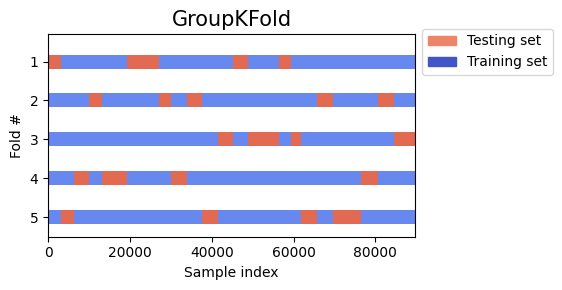

In [8]:
my_groups = np.array(data['PatientID'])
this_cv = GroupKFold(n_splits=n_splits)
fig, ax = plt.subplots(figsize=(6, 3))
plot_cv_indices(this_cv, X, y, my_groups, ax, n_splits)

ax.legend([Patch(color=cmap_cv(.8)), Patch(color=cmap_cv(.02))],
              ['Testing set', 'Training set'], loc=(1.02, .8))
# Make the legend fit
plt.tight_layout()
fig.subplots_adjust(right=.7)
plt.show()